# NSB Rate vs Observing Time: LST Tracking the Crab Nebula

This notebook shows how to estimate the median NSB rate seen by a CTAO LST-1 telescope as a function of time during a realistic observation run — tracking the Crab Nebula from the CTAO North site across a single night.

On the chosen night (2022-01-22/23) the Moon rises around 21:00 UTC, letting us watch moonlight progressively dominate the NSB budget as the observation proceeds.

In [1]:
import astropy
import astropy.time
import astropy.units as u
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import AltAz, SkyCoord, SkyOffsetFrame, get_body

from nsb2.atmosphere import SingleScatteringAtmosphere
from nsb2.core.lightpath import DirectPath, ScatteredPath
from nsb2.core.pipeline import Pipeline
from nsb2.emitter import airglow, moon, zodiacal
from nsb2.instrument import CTAO

## 1. Build the model

We use three diffuse sources that are always present in an NSB simulation:

| Source | Factory | Notes |
|---|---|---|
| Airglow | `airglow.from_eso_skycalc` | Van Rhijn-scaled ESO SkyCal spectrum |
| Zodiacal light | `zodiacal.from_leinert1998` | Leinert 1998 summary table |
| Moonlight | `moon.from_noll2013` | Noll 2013 ROLO model; returns empty field when below the horizon |

Stars are omitted here for speed — see the LST Tutorial for a full treatment with `LUTDirectSolver` / `LUTScatteredSolver`.

In [2]:
glow = airglow.from_eso_skycalc(87 * u.km, 100)
zodi = zodiacal.from_leinert1998()
noll13 = moon.from_noll2013()


def X(Z):
    return 1 / (np.cos(Z) + 0.50572 * (96.07995 - np.rad2deg(Z)) ** (-1.6364))


atmo = SingleScatteringAtmosphere(
    X,
    lambda lam: 0.00879 * lam.to(u.micron).value ** (-4.09) * np.exp(-8 / 8),
    lambda lam: 0.5 * (lam.to(u.nm).value / 380) ** (-1) * np.exp(-1.8 / 1.54),
    lambda lam: np.zeros(lam.shape),
    0.8,
)

lst1 = CTAO.LST1North()
model = Pipeline(lst1, atmo, [glow, zodi, noll13], paths=[DirectPath(), ScatteredPath(nside=16)])

## 2. Set up the scan

The CTAO North site is at La Palma (lon 17.89 °E, lat 28.76 °N, 2200 m a.s.l.). We track the Crab Nebula — the standard CTAO calibration target at RA 83.82°, Dec +22.01° — from 19:30 UTC until it sets below ~10° altitude near 02:30 UTC, sampling every 30 minutes (15 snapshots, ~25 s total compute).

In [3]:
location = astropy.coordinates.EarthLocation.from_geodetic(17.89, 28.76, 2.2 * u.km)
crab = SkyCoord.from_name("Crab Nebula")

t_start = astropy.time.Time("2022-01-22T19:30:00", format="isot", scale="utc")
n_steps = 15
obs_times = t_start + np.arange(n_steps) * 30 * u.min

print(
    f"Scanning {n_steps} time steps: {obs_times[0].isot[11:16]} – {obs_times[-1].isot[11:16]} UTC"
)

Scanning 15 time steps: 19:30 – 02:30 UTC


## 3. Run the time-series scan

At each snapshot we:

1. Construct the local `AltAz` frame for the site at that instant, including basic atmospheric refraction.
2. Transform the Crab Nebula's ICRS position into that frame to obtain the telescope pointing.
3. Wrap the pointing in a `SkyOffsetFrame` — the observation frame nsb2 uses.
4. Call `model.predict(observation)`, which returns one `Prediction` per (source, path) pair; each carries a `(N_pix, 3)` rate array (min / median / max spectral realisations).
5. Sum the median rates over all sources and paths to get the total per-pixel rate.

In [4]:
%%time
records = []
for t in obs_times:
    base = AltAz(
        obstime=t,
        location=location,
        pressure=790 * u.hPa,
        relative_humidity=0.1,
        temperature=5 * u.deg_C,
    )
    obs = SkyOffsetFrame(origin=crab.transform_to(base), rotation=0 * u.deg)
    preds = model.predict(obs)

    step = {
        "time": t.to_datetime(),
        "crab_alt": crab.transform_to(base).alt.deg,
        "moon_alt": get_body("moon", t).transform_to(base).alt.deg,
    }
    for p in preds:
        step[p.source_name] = step.get(p.source_name, 0.0) + p.rates.to(u.MHz)[:, 1].mean().value
    records.append(step)

source_names = [glow.name, zodi.name, noll13.name]
times_dt = [r["time"] for r in records]

CPU times: user 19.6 s, sys: 1.23 s, total: 20.8 s
Wall time: 20.8 s


## 4. NSB rate over time

The stacked area chart shows each source's contribution independently. The Moon and Crab altitudes are overlaid on a secondary axis to explain the trends:

- The **airglow** and **zodiacal light** bands are nearly flat while the Crab is above the horizon (their airmass correction is small at high altitude).
- The **moonlight** band is zero while the Moon is below the horizon, then rises rapidly as the Moon climbs — it overtakes airglow + zodiacal light within a couple of hours of moonrise.

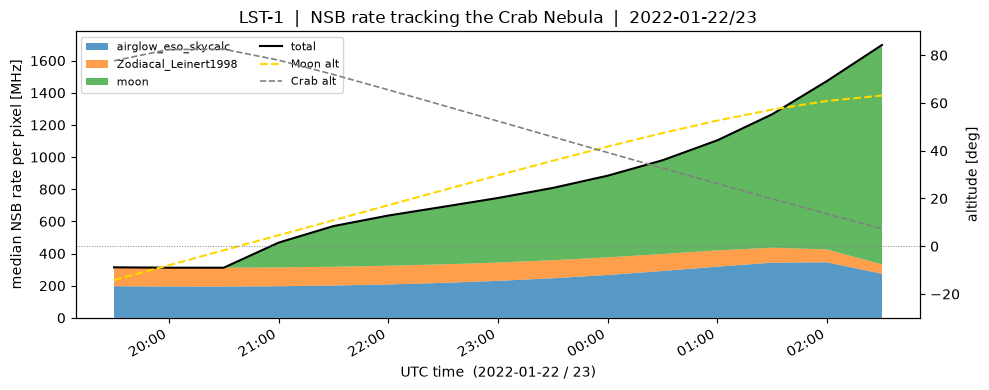

In [5]:
stack = np.array([[r.get(name, 0.0) for r in records] for name in source_names])
total = stack.sum(axis=0)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.stackplot(times_dt, stack, labels=source_names, alpha=0.75)
ax1.plot(times_dt, total, "k-", lw=1.5, label="total")
ax1.set_ylabel("median NSB rate per pixel [MHz]")
ax1.set_xlabel("UTC time  (2022-01-22 / 23)")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax1.xaxis.set_major_locator(mdates.HourLocator())
fig.autofmt_xdate(rotation=30, ha="right")

ax2 = ax1.twinx()
ax2.plot(times_dt, [r["moon_alt"] for r in records], "--", color="gold", lw=1.5, label="Moon alt")
ax2.plot(times_dt, [r["crab_alt"] for r in records], "--", color="grey", lw=1.2, label="Crab alt")
ax2.axhline(0, color="grey", lw=0.7, ls=":")
ax2.set_ylabel("altitude [deg]")
ax2.set_ylim(-30, 90)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8, ncol=2)
ax1.set_title("LST-1  |  NSB rate tracking the Crab Nebula  |  2022-01-22/23")
fig.tight_layout()

## 5. Camera view at peak moonlight

The per-pixel `rates` array carries spatial information — each entry corresponds to a camera pixel. Below we pick the final snapshot (Moon near 60° altitude, highest moonlight contribution) and display the total NSB rate across the LSTCam geometry using ctapipe's `CameraDisplay`.

/home/sspencer/ctapipe/src/ctapipe/instrument/camera/geometry.py:643: FromNameWarning: .from_name uses pre-defined data that is likely different from the data being analyzed. Access instrument information via the SubarrayDescription instead.
  warn_from_name()


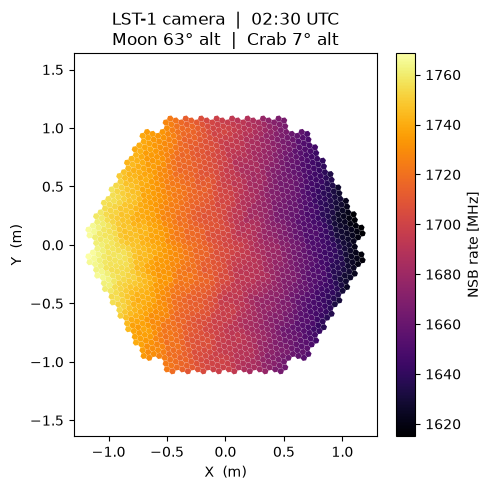

In [6]:
from ctapipe.instrument import CameraGeometry
from ctapipe.visualization import CameraDisplay

cam = CameraGeometry.from_name("LSTCam")

# Recompute at the last (brightest) time step to get the full pixel array
t_peak = obs_times[-1]
base_peak = AltAz(
    obstime=t_peak,
    location=location,
    pressure=790 * u.hPa,
    relative_humidity=0.1,
    temperature=5 * u.deg_C,
)
obs_peak = SkyOffsetFrame(origin=crab.transform_to(base_peak), rotation=0 * u.deg)
preds_peak = model.predict(obs_peak)

total_pixel = sum(p.rates.to(u.MHz)[:, 1].value for p in preds_peak)

fig, ax = plt.subplots(figsize=(5, 5))
disp = CameraDisplay(cam, ax=ax, show_frame=False)
disp.image = total_pixel
disp.add_colorbar(label="NSB rate [MHz]")
r = records[-1]
ax.set_title(
    f"LST-1 camera  |  {t_peak.isot[11:16]} UTC\n"
    f"Moon {r['moon_alt']:.0f}\u00b0 alt  |  Crab {r['crab_alt']:.0f}\u00b0 alt"
)
fig.tight_layout()